## Stability Analysis (Combined Results Based on F1 Score)

### Imports and configuration

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import rankdata, friedmanchisquare
import scikit_posthocs as sp

OUTPUT_DIR = "Statistical Justification"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DPI = 600
TOP_K = 10

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 14,
})

def save_and_show(fig, filename):
    fig.savefig(os.path.join(OUTPUT_DIR, filename), dpi=DPI, bbox_inches="tight")
    plt.show()

### F1 Score of Combined Traces

In [2]:
fs_names = ["ANOVA", "CORR", "FLAML", "PSO", "WOA"]
model_names = ["CNN", "MLP", "LeNet", "MDCNN", "NN", "LSTM", "RNN", "Transformer", "BERT", "DistilGPT2"]

data = np.array([
    [0.97, 0.98, 0.97, 0.98, 0.98, 0.94, 0.95, 0.95, 0.97, 0.97],  # ANOVA
    [0.98, 0.99, 0.98, 0.99, 0.99, 0.98, 0.98, 0.97, 0.95, 0.96],  # CORR
    [0.98, 0.99, 0.99, 0.99, 0.99, 0.98, 0.97, 0.97, 0.97, 0.98],  # FLAML
    [0.98, 0.99, 0.98, 0.99, 0.99, 0.97, 0.95, 0.98, 0.97, 0.97],  # PSO
    [0.98, 0.99, 0.98, 0.99, 0.99, 0.98, 0.98, 0.98, 0.98, 0.98],  # WOA
])

df = pd.DataFrame(data, index=fs_names, columns=model_names)
df

,CNN,MLP,LeNet,MDCNN,NN,LSTM,RNN,Transformer,BERT,DistilGPT2
ANOVA,0.97,0.98,0.97,0.98,0.98,0.94,0.95,0.95,0.97,0.97
CORR,0.98,0.99,0.98,0.99,0.99,0.98,0.98,0.97,0.95,0.96
FLAML,0.98,0.99,0.99,0.99,0.99,0.98,0.97,0.97,0.97,0.98
PSO,0.98,0.99,0.98,0.99,0.99,0.97,0.95,0.98,0.97,0.97
WOA,0.98,0.99,0.98,0.99,0.99,0.98,0.98,0.98,0.98,0.98


### Statistics once

Kendall’s W tells you “how strong is that difference?

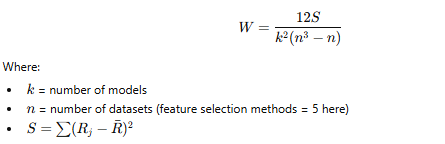

In [3]:
# ranks
ranks = np.array([rankdata(-row, method="average") for row in data])
avg_ranks = ranks.mean(axis=0)
rank_series = pd.Series(avg_ranks, index=model_names).sort_values()

# Friedman test
friedman_stat, friedman_p = friedmanchisquare(*[data[:, i] for i in range(data.shape[1])])

# Tie-corrected Kendall's W aligned with Friedman
n, k = data.shape
kendalls_w = friedman_stat / (n * (k - 1))

# Nemenyi post-hoc
nemenyi_df = sp.posthoc_nemenyi_friedman(data)
nemenyi_df.index = model_names
nemenyi_df.columns = model_names

print(f"Friedman statistic : {friedman_stat:.6f}")
print(f"Friedman p-value   : {friedman_p:.6f}")
print(f"Kendall's W        : {kendalls_w:.6f}")
print("\nAverage ranks (lower is better):")
print(rank_series)

Friedman statistic : 36.165722
Friedman p-value   : 0.000037
Kendall's W        : 0.803683

Average ranks (lower is better):
MLP            2.1
MDCNN          2.1
NN             2.1
LeNet          5.1
CNN            5.8
DistilGPT2     7.1
LSTM           7.3
Transformer    7.5
BERT           7.9
RNN            8.0
dtype: float64


### Full heatmap

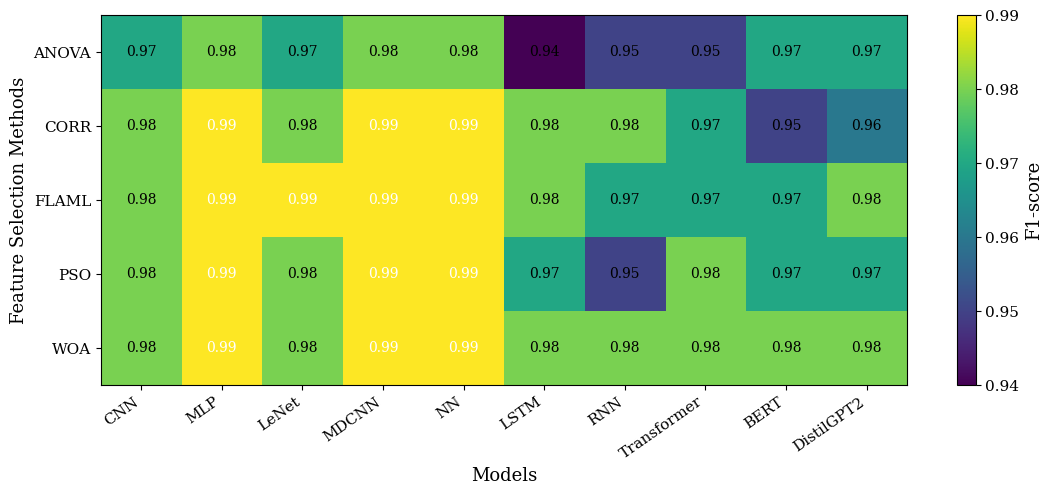

In [4]:
fig, ax = plt.subplots(figsize=(13, 4.8))
im = ax.imshow(df.values, aspect="auto")

ax.set_xticks(np.arange(len(df.columns)))
ax.set_yticks(np.arange(len(df.index)))
ax.set_xticklabels(df.columns, rotation=35, ha="right")
ax.set_yticklabels(df.index)

for i in range(df.shape[0]):
    for j in range(df.shape[1]):
        val = df.iloc[i, j]
        ax.text(j, i, f"{val:.2f}",
                ha="center", va="center",
                fontsize=10,
                color="white" if val >= 0.985 else "black")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("F1-score")

ax.set_xlabel("Models")
ax.set_ylabel("Feature Selection Methods")

save_and_show(fig, "figure_01_Heatmap of Model Performance Across Feature Selection Methods.png")

### Category-wise heatmaps

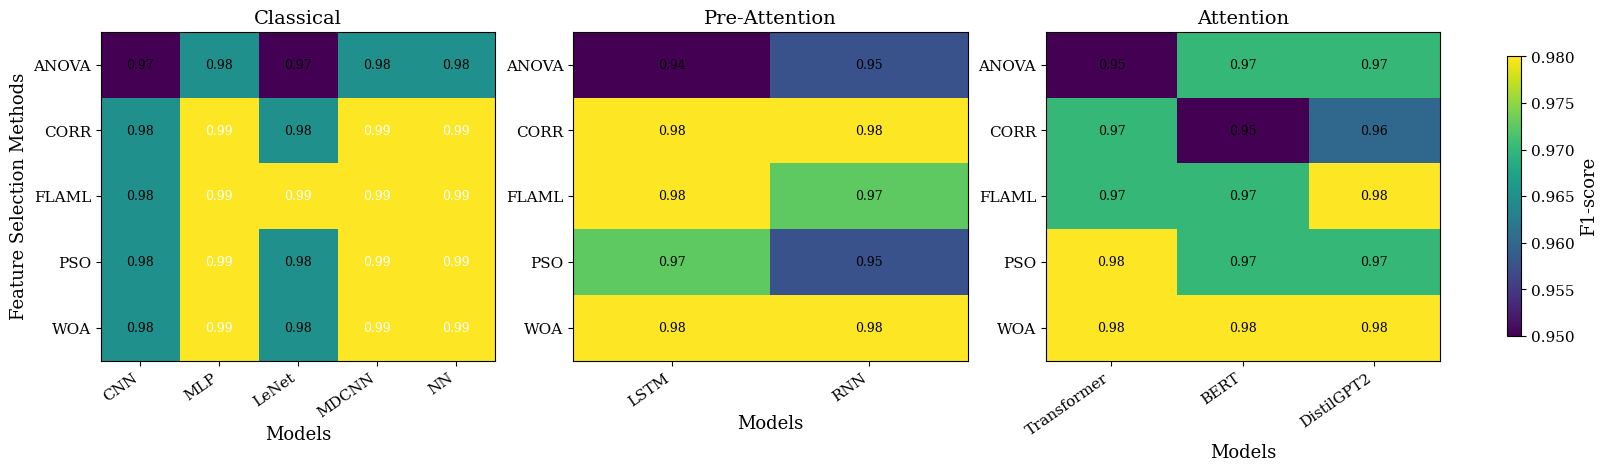

In [5]:
categories = {
    "Classical": ["CNN", "MLP", "LeNet", "MDCNN", "NN"],
    "Pre-Attention": ["LSTM", "RNN"],
    "Attention": ["Transformer", "BERT", "DistilGPT2"],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)

last_im = None
for ax, (cat_name, cols) in zip(axes, categories.items()):
    sub_df = df[cols]
    last_im = ax.imshow(sub_df.values, aspect="auto")

    ax.set_xticks(np.arange(len(sub_df.columns)))
    ax.set_yticks(np.arange(len(sub_df.index)))
    ax.set_xticklabels(sub_df.columns, rotation=35, ha="right")
    ax.set_yticklabels(sub_df.index)

    for i in range(sub_df.shape[0]):
        for j in range(sub_df.shape[1]):
            val = sub_df.iloc[i, j]
            ax.text(j, i, f"{val:.2f}",
                    ha="center", va="center",
                    fontsize=9,
                    color="white" if val >= 0.985 else "black")

    ax.set_title(cat_name)
    ax.set_xlabel("Models")

axes[0].set_ylabel("Feature Selection Methods")
cbar = fig.colorbar(last_im, ax=axes, shrink=0.85)
cbar.set_label("F1-score")

save_and_show(fig, "figure_02_Category-wise Heatmaps of Model Performance.png")

### Average-rank bar plot

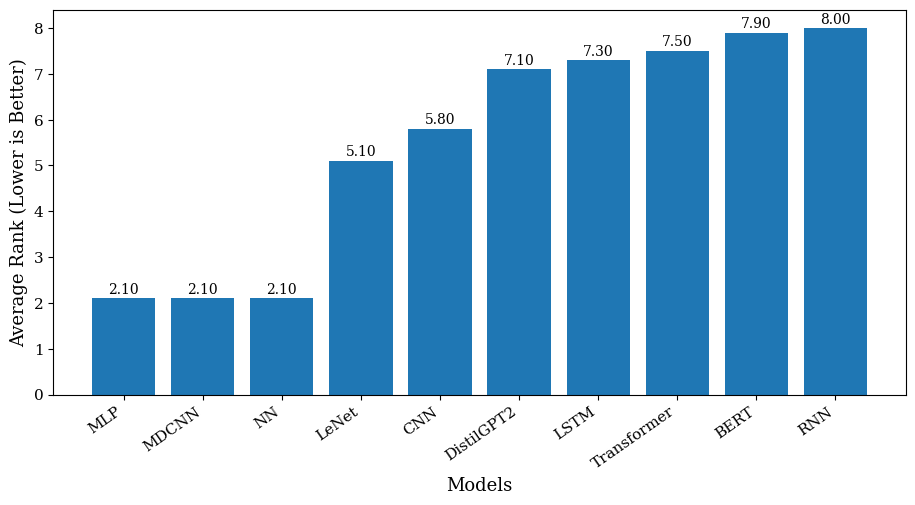

In [6]:
rank_df = pd.DataFrame({
    "Model": model_names,
    "Average Rank": avg_ranks
}).sort_values("Average Rank", ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(rank_df))
bars = ax.bar(x, rank_df["Average Rank"].values)

ax.set_xticks(x)
ax.set_xticklabels(rank_df["Model"].values, rotation=35, ha="right")
ax.set_ylabel("Average Rank (Lower is Better)")
ax.set_xlabel("Models")

for rect, val in zip(bars, rank_df["Average Rank"].values):
    ax.text(rect.get_x() + rect.get_width() / 2,
            rect.get_height() + 0.04,
            f"{val:.2f}",
            ha="center", va="bottom", fontsize=10)

save_and_show(fig, "figure_03_Average Model Ranking Across Feature Selection Methods.png")

### Critical difference diagram

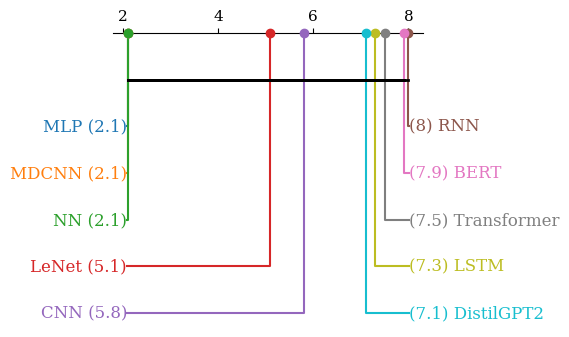

In [7]:
fig, ax = plt.subplots(figsize=(4, 4))
sp.critical_difference_diagram(rank_series, nemenyi_df, ax=ax)

save_and_show(fig, "figure_05_Critical Difference Diagram (Friedman + Nemenyi).png")

### Stability plot

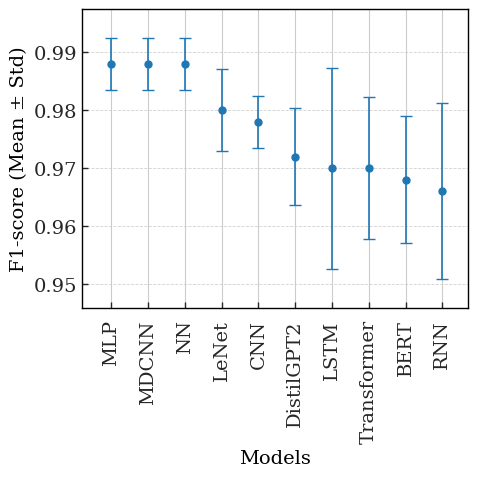

In [40]:
means = df.mean(axis=0)
stds = df.std(axis=0)

stability_df = pd.DataFrame({
    "Model": df.columns,
    "Mean": means.values,
    "Std": stds.values
}).sort_values("Mean", ascending=False).reset_index(drop=True)


plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

fig, ax = plt.subplots(figsize=(5, 5))  # better aspect ratio

x = np.arange(len(stability_df))

ax.errorbar(
    x,
    stability_df["Mean"].values,
    yerr=stability_df["Std"].values,
    fmt="o",
    capsize=4,
    elinewidth=1.2,
    markersize=5,
    linewidth=1
)


ax.set_xticks(x)
ax.set_xticklabels(
    stability_df["Model"].values,
    rotation=90,
    ha="center",     # center align (fixes tilt imbalance)
    va="top"         # clean vertical stacking
)

# Add padding between ticks and labels
ax.tick_params(axis='x', pad=8)

ax.set_ylabel("F1-score (Mean ± Std)")
ax.set_xlabel("Models")


lower = (stability_df["Mean"] - stability_df["Std"]).min()
upper = (stability_df["Mean"] + stability_df["Std"]).max()

padding = 0.005  # small visual breathing space

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)   # bold
    spine.set_color("black")

ax.set_ylim(lower - padding, upper + padding)

ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.9)
ax.tick_params(direction="in", length=4, width=1)
ax.xaxis.label.set_color("black")
ax.yaxis.label.set_color("black")
ax.set_xlim(-0.8, len(x) - 0.3)   # adds space on both sides

plt.tight_layout()

save_and_show(fig,"figure_04_Performance_Stability.png")

### Nemenyi heatmap

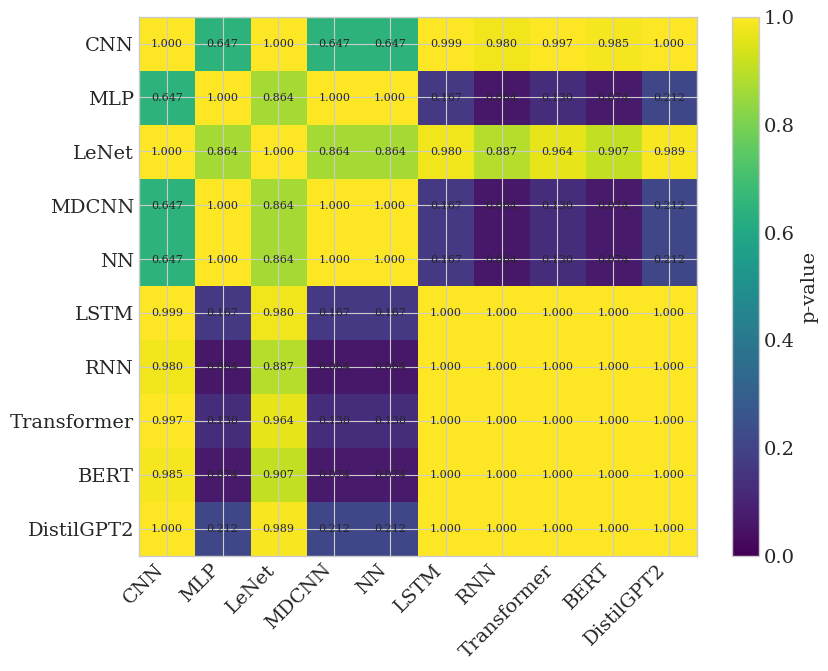

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(
    nemenyi_df.values,
    aspect="auto",
    cmap="viridis",
    vmin=0, vmax=1   # p-values always in [0,1]
)

ax.set_xticks(np.arange(len(nemenyi_df.columns)))
ax.set_yticks(np.arange(len(nemenyi_df.index)))
ax.set_xticklabels(nemenyi_df.columns, rotation=45, ha="right")
ax.set_yticklabels(nemenyi_df.index)

for i in range(nemenyi_df.shape[0]):
    for j in range(nemenyi_df.shape[1]):
        ax.text(j, i, f"{nemenyi_df.iloc[i, j]:.3f}",
                ha="center", va="center", fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("p-value")

save_and_show(fig, "figure_06_Nemenyi Post-hoc Test p-value Matrix.png")

### Top-k combinations

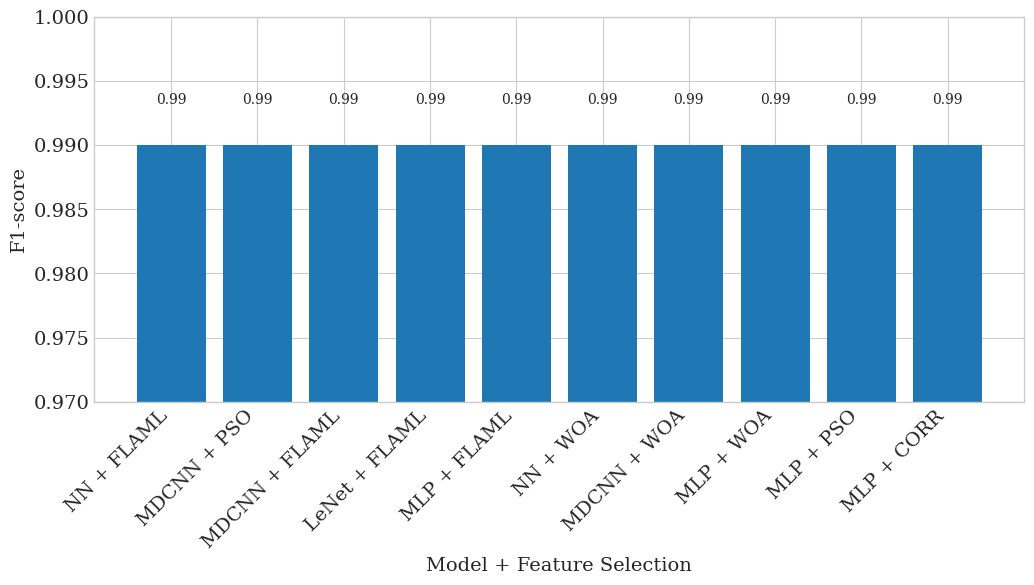

In [10]:
combos = []
for fs in df.index:
    for model in df.columns:
        combos.append((f"{model} + {fs}", df.loc[fs, model]))

combo_df = pd.DataFrame(combos, columns=["Combination", "F1"])
combo_df = combo_df.sort_values(by="F1", ascending=False).head(TOP_K)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(combo_df))
bars = ax.bar(x, combo_df["F1"].values)

ax.set_xticks(x)
ax.set_xticklabels(combo_df["Combination"].values, rotation=45, ha="right")
ax.set_ylabel("F1-score")
ax.set_xlabel("Model + Feature Selection")
ax.set_ylim(combo_df["F1"].min() - 0.02, 1.0)

for rect, val in zip(bars, combo_df["F1"].values):
    ax.text(rect.get_x() + rect.get_width() / 2,
            val + 0.003,
            f"{val:.2f}",
            ha="center", va="bottom", fontsize=10)

save_and_show(fig, "figure_07_Top-10 Model–Feature Selection Combinations.png")

### Win, tie, and loss matrices

In [11]:
models = df.columns.tolist()
wins = pd.DataFrame(0, index=models, columns=models, dtype=int)
ties = pd.DataFrame(0, index=models, columns=models, dtype=int)
losses = pd.DataFrame(0, index=models, columns=models, dtype=int)

for m1 in models:
    for m2 in models:
        if m1 == m2:
            continue
        for fs in df.index:
            v1 = df.loc[fs, m1]
            v2 = df.loc[fs, m2]
            if v1 > v2:
                wins.loc[m1, m2] += 1
            elif v1 < v2:
                losses.loc[m1, m2] += 1
            else:
                ties.loc[m1, m2] += 1

### Win matrix

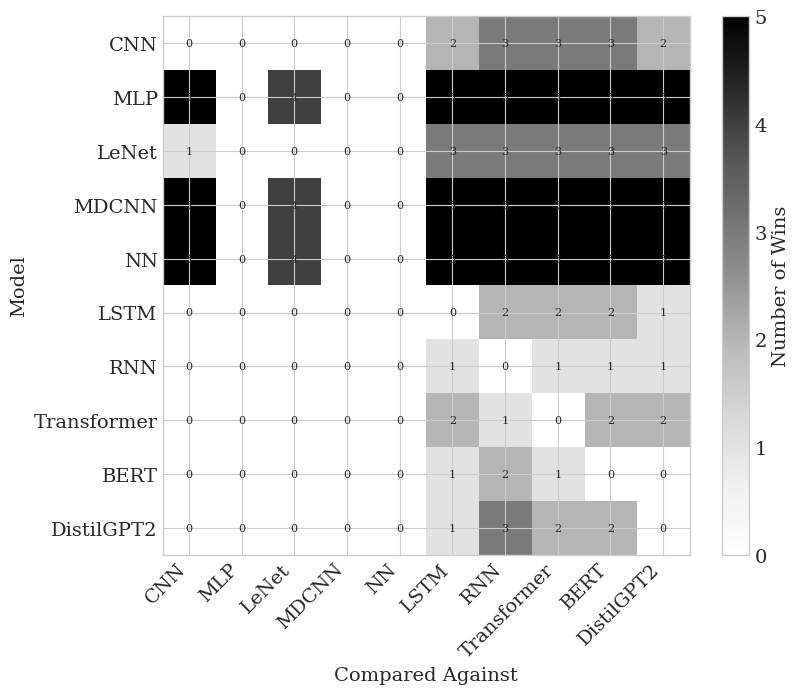

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(wins.values, aspect="auto")

ax.set_xticks(np.arange(len(wins.columns)))
ax.set_yticks(np.arange(len(wins.index)))
ax.set_xticklabels(wins.columns, rotation=45, ha="right")
ax.set_yticklabels(wins.index)

for i in range(wins.shape[0]):
    for j in range(wins.shape[1]):
        ax.text(j, i, str(wins.iloc[i, j]), ha="center", va="center", fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Number of Wins")
ax.set_xlabel("Compared Against")
ax.set_ylabel("Model")

save_and_show(fig, "figure_08_Win Matrix Across Feature Selection Methods.png")

### Tie matrix

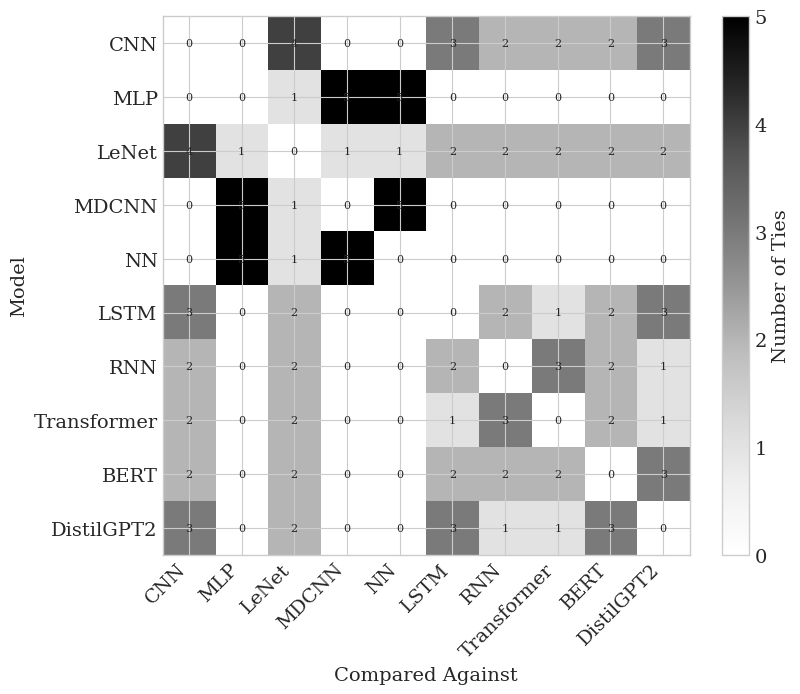

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(ties.values, aspect="auto")

ax.set_xticks(np.arange(len(ties.columns)))
ax.set_yticks(np.arange(len(ties.index)))
ax.set_xticklabels(ties.columns, rotation=45, ha="right")
ax.set_yticklabels(ties.index)

for i in range(ties.shape[0]):
    for j in range(ties.shape[1]):
        ax.text(j, i, str(ties.iloc[i, j]), ha="center", va="center", fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Number of Ties")
ax.set_xlabel("Compared Against")
ax.set_ylabel("Model")

save_and_show(fig, "figure_09_Tie Matrix Across Feature Selection Methods.png")

### Loss matrix

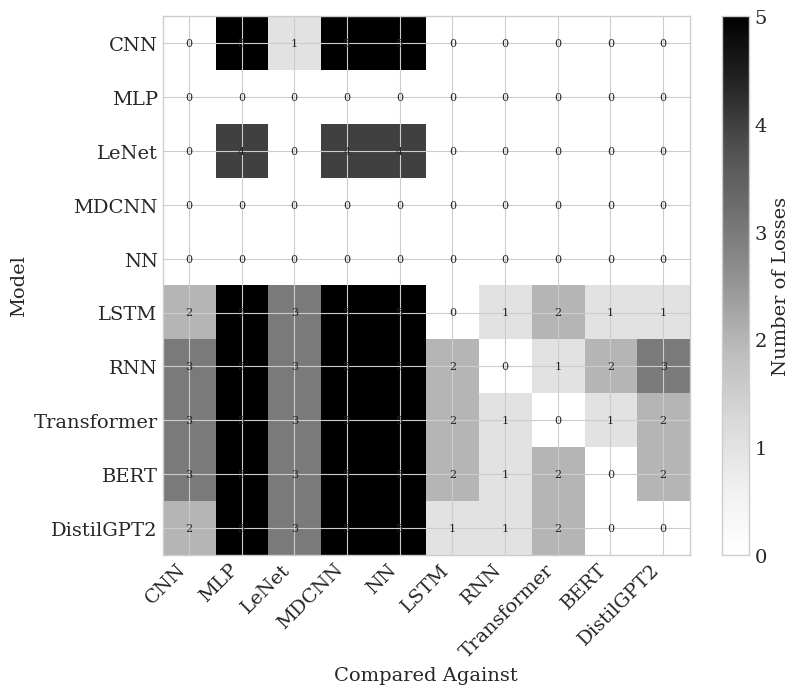

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(losses.values, aspect="auto")

ax.set_xticks(np.arange(len(losses.columns)))
ax.set_yticks(np.arange(len(losses.index)))
ax.set_xticklabels(losses.columns, rotation=45, ha="right")
ax.set_yticklabels(losses.index)

for i in range(losses.shape[0]):
    for j in range(losses.shape[1]):
        ax.text(j, i, str(losses.iloc[i, j]), ha="center", va="center", fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Number of Losses")
ax.set_xlabel("Compared Against")
ax.set_ylabel("Model")

save_and_show(fig, "figure_10_Loss Matrix Across Feature Selection Methods.png")

### Dominance heatmap

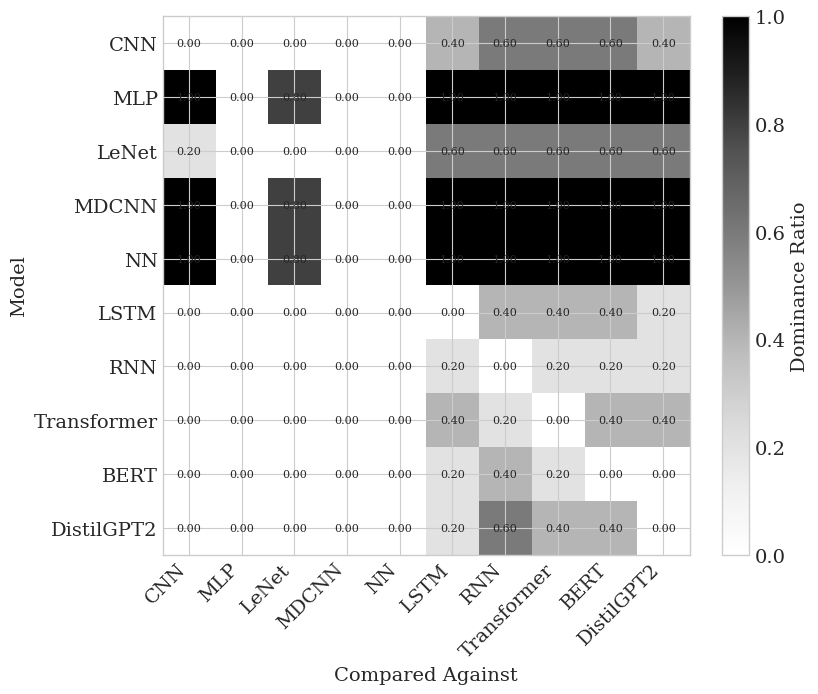

In [15]:
dominance = wins / len(df.index)

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(dominance.values, aspect="auto", vmin=0, vmax=1)

ax.set_xticks(np.arange(len(dominance.columns)))
ax.set_yticks(np.arange(len(dominance.index)))
ax.set_xticklabels(dominance.columns, rotation=45, ha="right")
ax.set_yticklabels(dominance.index)

for i in range(dominance.shape[0]):
    for j in range(dominance.shape[1]):
        ax.text(j, i, f"{dominance.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Dominance Ratio")
ax.set_xlabel("Compared Against")
ax.set_ylabel("Model")

save_and_show(fig, "figure_11_Dominance Heatmap Across Feature Selection Methods.png")

### Performance profile

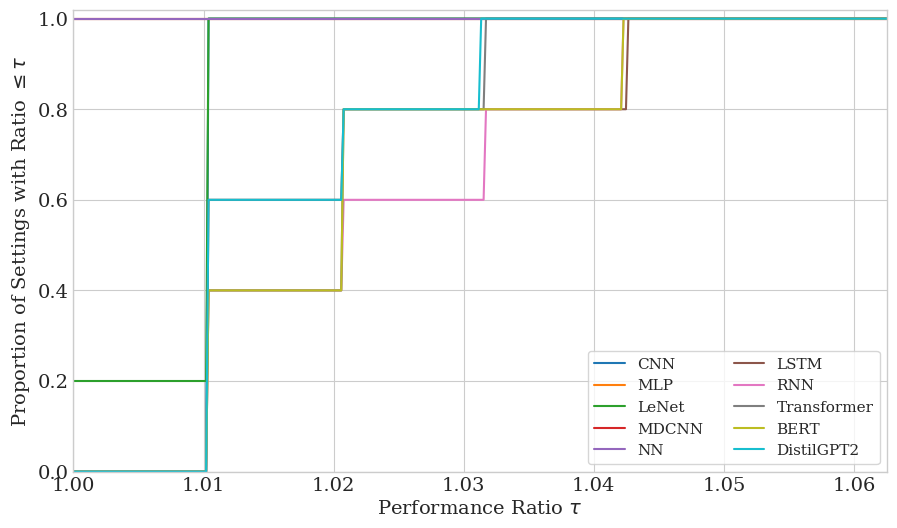

In [16]:
score_matrix = df.values
best_per_block = score_matrix.max(axis=1, keepdims=True)
ratios = best_per_block / score_matrix

taus = np.linspace(1.0, np.max(ratios) + 0.05, 500)

fig, ax = plt.subplots(figsize=(10.5, 6))

for j, model in enumerate(df.columns):
    probs = [(ratios[:, j] <= tau).mean() for tau in taus]
    ax.plot(taus, probs, label=model)

ax.set_xlabel(r"Performance Ratio $\tau$")
ax.set_ylabel(r"Proportion of Settings with Ratio $\leq \tau$")
ax.set_ylim(0, 1.02)
ax.set_xlim(1.0, np.max(ratios) + 0.02)
ax.legend(loc="lower right", ncol=2, frameon=True)

save_and_show(fig, "figure_12_Performance Profile Across Feature Selection Methods.png")

### Compact summary table

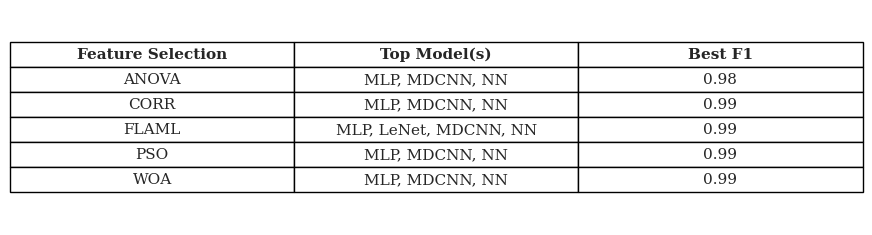

In [17]:
rows = []
for fs in df.index:
    row = df.loc[fs]
    max_val = row.max()
    best_models = row[row == max_val].index.tolist()
    rows.append([fs, ", ".join(best_models), f"{max_val:.2f}"])

summary_df = pd.DataFrame(rows, columns=["Feature Selection", "Top Model(s)", "Best F1"])

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.axis("off")

table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.1, 1.5)

for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_text_props(weight="bold")

summary_df.to_csv(os.path.join(OUTPUT_DIR, "table_summary_best_models.csv"), index=False)
save_and_show(fig, "figure_13_Compact Summary of Best-Performing Models.png")

### Mean–Std–Rank summary - Confidence Intervals (CI) - Robustness

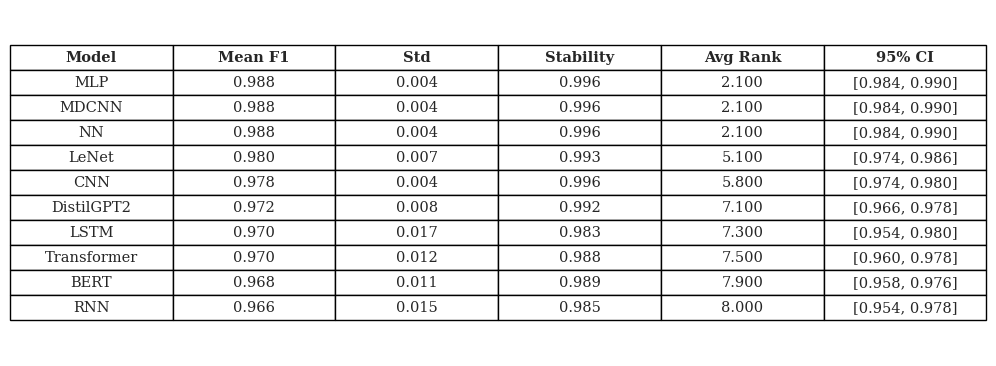

,Model,Mean F1,Std,Stability,Avg Rank,CI Low,CI High
1,MLP,0.988,0.004472,0.995528,2.1,0.984,0.990
3,MDCNN,0.988,0.004472,0.995528,2.1,0.984,0.990
4,NN,0.988,0.004472,0.995528,2.1,0.984,0.990
2,LeNet,0.980,0.007071,0.992929,5.1,0.974,0.986
0,CNN,0.978,0.004472,0.995528,5.8,0.974,0.980
9,DistilGPT2,0.972,0.008367,0.991633,7.1,0.966,0.978
5,LSTM,0.970,0.017321,0.982679,7.3,0.954,0.980
7,Transformer,0.970,0.012247,0.987753,7.5,0.960,0.978
8,BERT,0.968,0.010954,0.989046,7.9,0.958,0.976
6,RNN,0.966,0.015166,0.984834,8.0,0.954,0.978


In [18]:
def bootstrap_ci(values, n_boot=3000, ci=95, random_state=42):
    rng = np.random.default_rng(random_state)
    means = []
    values = np.array(values)
    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        means.append(np.mean(sample))
    alpha = (100 - ci) / 2
    low, high = np.percentile(means, [alpha, 100 - alpha])
    return low, high


rows = []
for idx, model in enumerate(df.columns):
    values = df[model].values
    mean_val = np.mean(values)
    std_val = np.std(values, ddof=1)

    stability = 1 - std_val

    ci_low, ci_high = bootstrap_ci(values, random_state=idx + 123)

    rows.append([
        model,
        mean_val,
        std_val,
        stability,
        avg_ranks[idx],
        ci_low,
        ci_high
    ])


stats_df = pd.DataFrame(
    rows,
    columns=["Model", "Mean F1", "Std", "Stability", "Avg Rank", "CI Low", "CI High"]
).sort_values("Avg Rank", ascending=True)


# =========================
# Formatting
# =========================
display_df = stats_df.copy()

display_df["Mean F1"] = display_df["Mean F1"].map(lambda x: f"{x:.3f}")
display_df["Std"] = display_df["Std"].map(lambda x: f"{x:.3f}")
display_df["Stability"] = display_df["Stability"].map(lambda x: f"{x:.3f}")
display_df["Avg Rank"] = display_df["Avg Rank"].map(lambda x: f"{x:.3f}")
display_df["95% CI"] = stats_df.apply(
    lambda r: f"[{r['CI Low']:.3f}, {r['CI High']:.3f}]", axis=1
)

display_df = display_df[
    ["Model", "Mean F1", "Std", "Stability", "Avg Rank", "95% CI"]
]


# =========================
# Table Plot
# =========================
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.axis("off")

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc="center",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(10.5)
table.scale(1.05, 1.5)

# Bold header
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_text_props(weight="bold")


# =========================
# Save
# =========================
stats_df.to_csv(os.path.join(OUTPUT_DIR, "Mean–Std–Rank Summary of Models.csv"), index=False)

save_and_show(fig, "figure_14_Mean–Std–Rank Summary of Models.png")

stats_df

### Feature Selection vs Model Impact

In [19]:
# variance across models (for each FS)
var_models = np.var(data, axis=1).mean()

# variance across FS (for each model)
var_fs = np.var(data, axis=0).mean()

print(f"Variance due to models: {var_fs:.6f}")
print(f"Variance due to feature selection: {var_models:.6f}")

Variance due to models: 0.000080
Variance due to feature selection: 0.000115


The variance analysis reveals that model selection contributes more significantly to performance variation than feature selection, indicating that architectural choice plays a dominant role in detection effectiveness.

### Export data and report

In [20]:
df.to_csv(os.path.join(OUTPUT_DIR, "table_full_scores.csv"))

report_lines = []
report_lines.append("=" * 72)
report_lines.append("STATISTICAL ANALYSIS REPORT")
report_lines.append("=" * 72)
report_lines.append(f"Friedman statistic : {friedman_stat:.6f}")
report_lines.append(f"Friedman p-value   : {friedman_p:.6f}")
report_lines.append(f"Kendall's W        : {kendalls_w:.6f}")
report_lines.append("")
report_lines.append("Average ranks (lower is better):")
report_lines.append(rank_series.to_string())
report_lines.append("")
report_lines.append("Nemenyi p-value matrix:")
report_lines.append(nemenyi_df.to_string())

report_text = "\n".join(report_lines)

with open(os.path.join(OUTPUT_DIR, "statistical_report.txt"), "w", encoding="utf-8") as f:
    f.write(report_text)

print(report_text)
print("\nAll figures and tables saved in:", OUTPUT_DIR)

STATISTICAL ANALYSIS REPORT
Friedman statistic : 36.165722
Friedman p-value   : 0.000037
Kendall's W        : 0.803683

Average ranks (lower is better):
MLP            2.1
MDCNN          2.1
NN             2.1
LeNet          5.1
CNN            5.8
DistilGPT2     7.1
LSTM           7.3
Transformer    7.5
BERT           7.9
RNN            8.0

Nemenyi p-value matrix:
                  CNN       MLP     LeNet     MDCNN        NN      LSTM       RNN  Transformer      BERT  DistilGPT2
CNN          1.000000  0.646841  0.999998  0.646841  0.646841  0.998816  0.979527     0.996857  0.985157    0.999627
MLP          0.646841  1.000000  0.864285  1.000000  1.000000  0.167184  0.063818     0.129563  0.074109    0.212132
LeNet        0.999998  0.864285  1.000000  0.864285  0.864285  0.979527  0.886843     0.963510  0.906921    0.989497
MDCNN        0.646841  1.000000  0.864285  1.000000  1.000000  0.167184  0.063818     0.129563  0.074109    0.212132
NN           0.646841  1.000000  0.864285  1.00